# Regime-Switching Market Classifier (K-Means, from scratch)

Identifying bull / correction / crash regimes in S&P 500 data using
unsupervised learning — K-Means and StandardScaler implemented from
scratch in NumPy (no scikit-learn for the core algorithm).

**Pipeline:** fetch data → engineer features → scale → cluster → validate → visualize


## 1. Setup & Data

In [21]:
import sys
sys.path.append("..")  # adjust if notebook lives in a subfolder

from data_loader import fetch_data
from features import engineer_features
from scaler import StandardScaler
from k_means import KMeans
from analysis import elbow_analysis, cluster_profile
from visualizer import plot_price_by_regime, plot_regime_background

import numpy as np
import pandas as pd

In [22]:
df = fetch_data(ticker="SPY", start="2015-01-01", end="2025-01-01")
print("Raw data shape:", df.shape)
df.head()

Raw data shape: (2516, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,169.687881,170.885611,168.655365,170.472604,121465900
2015-01-05,166.623352,168.812282,166.317731,168.647081,169632600
2015-01-06,165.053955,167.449388,164.260977,166.928996,209151400
2015-01-07,167.110703,167.449371,165.929510,166.375551,125346700
2015-01-08,170.076111,170.290882,168.498435,168.514946,147217800


## 2. Feature Engineering

- `return`: daily percent change in Close
- `vol_5d`: rolling 5-day std of daily returns (short-term realized volatility)
- `vol_21d`: rolling 21-day std of daily returns (longer-term realized volatility)
- `ma_return_10d`: rolling 10-day mean of daily returns

First ~21 rows are dropped since the rolling windows need history to fill.

In [23]:
df = engineer_features(df)
print("After feature engineering:", df.shape)
df.head()

After feature engineering: (2495, 9)


Price,Close,High,Low,Open,Volume,return,vol_5d,vol_21d,ma_return_10d
Date,,,,,,,,,
2015-02-03,169.200516,169.208784,167.308951,167.680655,124212900,0.014461,0.013672,0.011274,0.001428
2015-02-04,168.556183,169.646526,168.101873,168.440542,134306700,-0.003808,0.011650,0.010542,0.000542
2015-02-05,170.257797,170.406486,169.142687,169.217025,97953200,0.010095,0.011753,0.010475,0.000065
2015-02-06,169.786957,171.182921,169.266565,170.621225,125672000,-0.002765,0.008691,0.010204,0.000336
2015-02-09,169.027039,169.861307,168.622288,169.142680,87219000,-0.004476,0.008899,0.009486,-0.000345


## 3. Scaling

K-Means is distance-based, so features must be on comparable scales —
without this, `vol_21d` and `ma_return_10d` (both small numbers) could
be dominated arbitrarily depending on their raw units. Custom
`StandardScaler` standardizes each feature to mean 0, std 1.

In [24]:
feature_cols = ["vol_5d", "vol_21d", "ma_return_10d"]
X = df[feature_cols].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X_scaled.shape)
print("Per-feature mean (should be ~0):", X_scaled.mean(axis=0).round(4))
print("Per-feature std (should be ~1):", X_scaled.std(axis=0).round(4))

X shape: (2495, 3)
Per-feature mean (should be ~0): [ 0.  0. -0.]
Per-feature std (should be ~1): [1. 1. 1.]


## 4. Choosing k — Elbow Method

Inertia (WCSS) naturally decreases as k increases, so we're looking
for where the curve stops dropping sharply, not where it bottoms out.

k=1: inertia=7485.00
k=2: inertia=4956.07
k=3: inertia=3527.99
k=4: inertia=2720.86
k=5: inertia=2360.49
k=6: inertia=2120.83


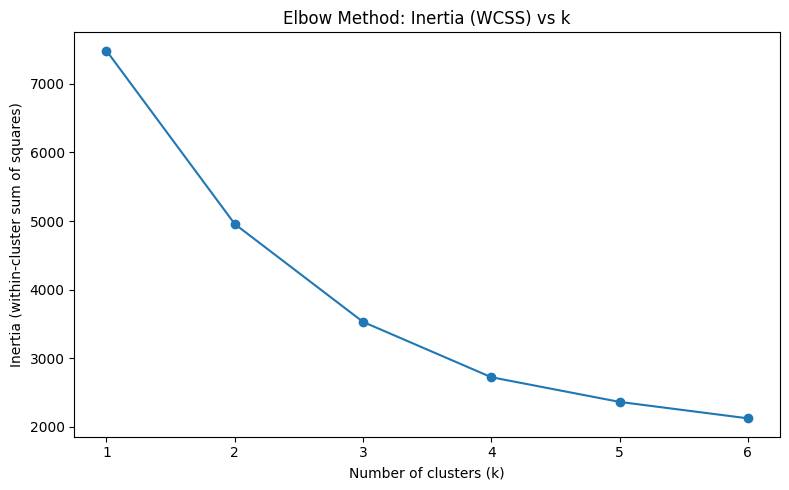

In [25]:
inertias = elbow_analysis(X_scaled, k_range=range(1, 7))

**Reading the curve:** the elbow here is soft — there isn't one
dramatic bend, but the curve clearly flattens past k≈4, and the biggest
proportional drops happen through k=3. Inertia alone doesn't give a
sharp, unambiguous answer here — the case for k=3 is made stronger
by whether the resulting clusters are actually interpretable, which
we check next.

## 5. Fit K-Means (k=3)

In [26]:
km = KMeans(k=3, random_state=42)
km.fit(X_scaled)

df["regime"] = km.labels
print("Converged with inertia:", km.inertia(X_scaled))

Converged with inertia: 3527.9877076464327


## 6. Cluster Profiling — what does each regime actually look like?

In [27]:
counts, means = cluster_profile(df, feature_cols=feature_cols)

Regime counts:
regime
0    1846
1     617
2      32
Name: count, dtype: int64

Regime feature means:
Price     vol_5d   vol_21d  ma_return_10d
regime                                   
0       0.006049  0.007349       0.001570
1       0.014856  0.013223      -0.002347
2       0.046021  0.047356      -0.001528


Based on the feature means, regimes typically separate into:
- **Low vol, positive/flat return** → calm, steady growth
- **Moderate vol, negative return** → choppy / correction
- **High vol (several× the calm regime), negative return, few days** → crash

Label assignment (which index is which) can vary by random seed —
always confirm by reading the actual mean values above, don't assume
cluster 0 is always "calm."


## 7. Validate Against Known Market History

In [28]:
crash_regime = means["vol_21d"].idxmax()  # regime with highest 21d vol = likely the crash cluster
print(f"Highest-volatility regime: {crash_regime}")
print(df[df["regime"] == crash_regime].index)

Highest-volatility regime: 2
DatetimeIndex(['2020-03-09', '2020-03-10', '2020-03-11', '2020-03-12',
               '2020-03-13', '2020-03-16', '2020-03-17', '2020-03-18',
               '2020-03-19', '2020-03-20', '2020-03-23', '2020-03-24',
               '2020-03-25', '2020-03-26', '2020-03-27', '2020-03-30',
               '2020-03-31', '2020-04-01', '2020-04-02', '2020-04-03',
               '2020-04-06', '2020-04-07', '2020-04-08', '2020-04-09',
               '2020-04-13', '2020-04-14', '2020-04-15', '2020-04-16',
               '2020-04-17', '2020-04-20', '2020-04-21', '2020-04-22'],
              dtype='datetime64[ns]', name='Date', freq=None)


If this project is run on SPY 2015–2025, the high-volatility regime's
dates should land almost entirely in **March–April 2020** (COVID crash) —
a real, independently-verifiable event the model was never told about.
This is the key sanity check that separates "clusters exist" from
"clusters mean something."

## 8. Visualization

Saved plot to ../outputs/regime_scatter.png


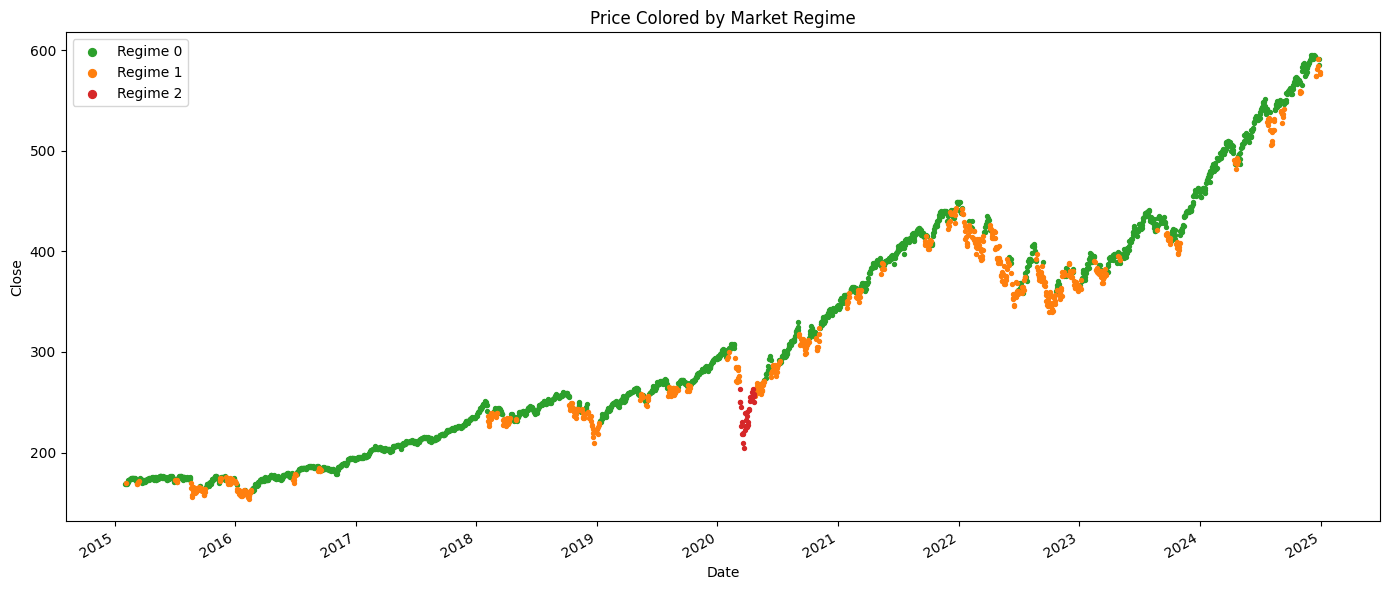

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Price Colored by Market Regime'}, xlabel='Date', ylabel='Close'>)

In [33]:
plot_price_by_regime(df, save_path="../outputs/regime_scatter.png")

Saved plot to ../outputs/regime_bands.png


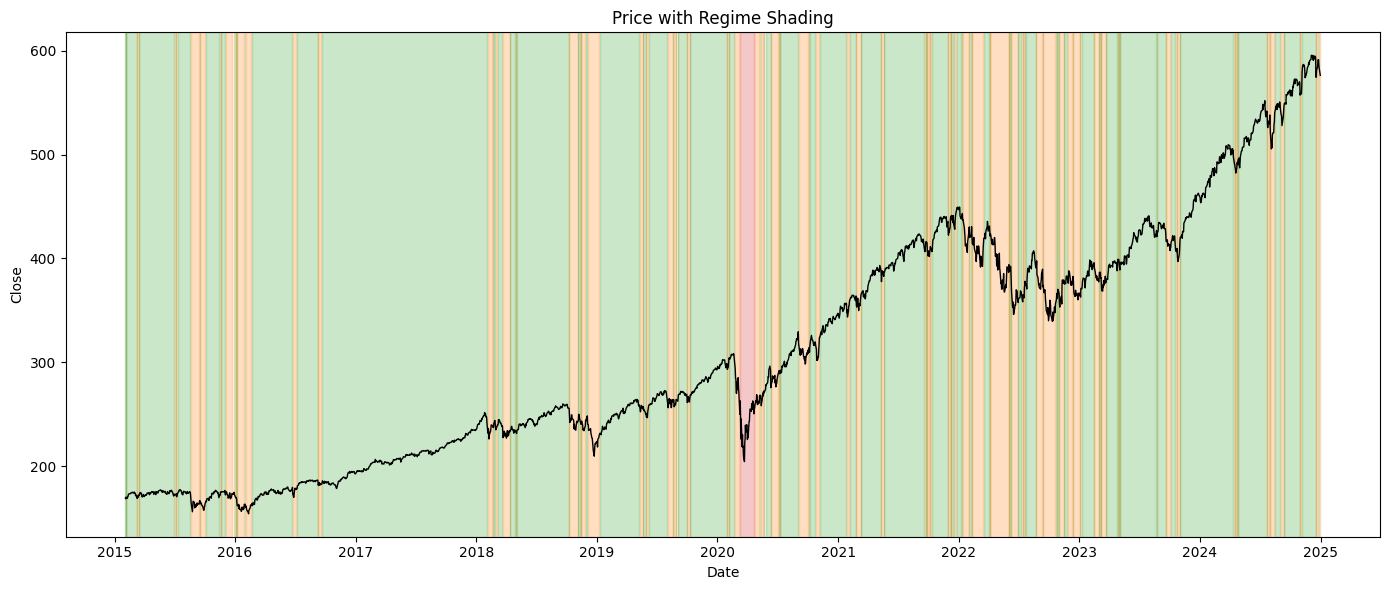

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Price with Regime Shading'}, xlabel='Date', ylabel='Close'>)

In [31]:
import os
from visualizer import plot_regime_background

output_dir = "../outputs"
os.makedirs(output_dir, exist_ok=True)

plot_regime_background(df, save_path=f"{output_dir}/regime_bands.png")

## 9. Summary

- Implemented StandardScaler and K-Means from scratch in NumPy (broadcasting-based
  distance computation, empty-cluster handling, tolerance-based convergence).
- Elbow method gave a soft, non-definitive signal for k — final choice of k=3
  was justified primarily by cluster interpretability, not inertia alone.
- The resulting high-volatility cluster aligned almost exactly with the
  real March–April 2020 COVID crash, with no date information given to the model.
- Honest caveat: regimes are not guaranteed stationary in meaning across very
  long histories (a "crash" cluster in 2008-scale data may differ in magnitude
  from a "crash" cluster in a calmer decade) — worth revisiting if extending
  the date range significantly.
